# Country Clustering Analysis using K-Means and HDBSCAN

This notebook performs clustering analysis on a dataset of countries using two different clustering algorithms: K-Means and HDBSCAN. The goal is to group countries based on various socioeconomic and development indicators to identify potential patterns and similarities.

The analysis includes:
- Data loading and preparation
- Applying K-Means clustering, including finding the optimal number of clusters
- Applying HDBSCAN clustering
- Visualizing and interpreting the results of both clustering methods, including cluster profiles and geographical representation.

> 💡 **Interactive Dashboard Available**
> 
> The interactive maps and the detailed lists of countries by cluster have been integrated into a Streamlit dashboard for a better and more dynamic user experience. 
> 
> **You can explore the clustering results interactively here:** https://wdi-global-clusters.streamlit.app/
> 
> *(Note: This notebook focuses on data preparation, model training, parameter tuning, and exporting the final `WDI2022_clusters.csv` dataset that feeds the dashboard.)*


## Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import hdbscan

## Reading and checking the dataset

In [2]:
file_path = '../WDI2022.csv'
df = pd.read_csv(file_path)

In [3]:
df.shape

(217, 19)

In [4]:
df.head()

,Country Name,Country Code,Region,corruption_perception_estimate,access_to_electricity_percent,co2_emissions_per_capita,mobile_cellular_subscriptions_per_100_people,agriculture_value_added_percent_gdp,industry_value_added_percent_gdp,gdp_growth_annual_percent,gdp_per_capita_usd,stability_of_government_estimate,health_expenditure_pct_gdp,child_mortality_rate,life_expectancy_at_birth,fertility_rate_total,population_65_plus_percent,population_total,urban_population_percent
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",-1.183684,85.30,0.203552,56.26550,33.701432,16.050368,-6.240172,357.261153,-2.544956,23.088169,52.00,65.617,4.932,2.355142,40578842.0,26.616
1,Albania,ALB,Europe & Central Asia,-0.408189,100.00,1.659293,98.39500,16.984478,23.025056,4.826696,6846.426694,0.106261,6.193681,8.30,78.769,1.355,15.776338,2777689.0,63.799
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",-0.638041,100.00,4.104114,107.78700,10.613178,43.048057,3.600000,4961.552577,-0.650652,3.623043,20.00,76.129,2.817,6.186964,45477389.0,74.772
3,American Samoa,ASM,East Asia & Pacific,1.270272,95.18,0.002069,122.31764,7.658086,19.785807,1.735016,18017.458938,1.123174,10.395107,19.12,72.752,2.305,7.103627,48342.0,87.196
4,Andorra,AND,Europe & Central Asia,1.270272,100.00,4.383951,142.42600,0.487492,11.145341,9.564612,42414.059009,1.585988,7.536788,2.60,84.016,1.071,14.968948,79705.0,87.811


## Data preparation and scaling

In [5]:
X = df.drop(['Country Name', 'Country Code', 'Region'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-Means

This section applies the K-Means clustering algorithm to the scaled data. It includes steps to determine the optimal number of clusters and visualize the results.

### Finding the ideal number of clusters (K)

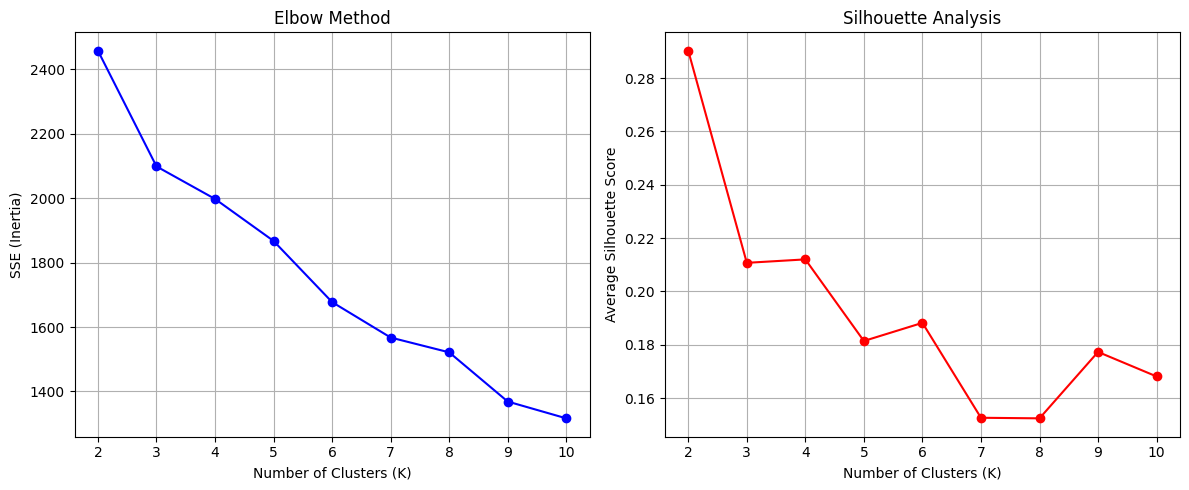

In the 'Elbow Method', look for the point where the curve smooths out.
In the 'Silhouette Analysis', look for the highest point (peak).


In [6]:
# Test from 2 to 10 clusters.
k_range = range(2, 11)
sse = [] # Sum of Squared Errors (for the Elbow Method)
silhouette_scores = [] # For Silhouette Analysis

for k in k_range:
    # K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)

    # For the Elbow Method
    sse.append(kmeans.inertia_)

    # For Silhouette Analysis
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting the Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, sse, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.grid(True)

# Plotting Silhouette Analysis
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)

plt.tight_layout()
plt.show()

print("In the 'Elbow Method', look for the point where the curve smooths out.")
print("In the 'Silhouette Analysis', look for the highest point (peak).")

### Applying K-Means with the ideal K

In [7]:
# After analysis, K=3 seems like a good choice.
OPTIMAL_K = 3

kmeans_clusterer = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init='auto')
clusters = kmeans_clusterer.fit_predict(X_scaled)

# Add the cluster number back to the original dataframe
df['Cluster_KMeans'] = clusters

### Analysis and interpretation of results

In [8]:
# 1. View the distribution of countries by cluster
print("\nCountry count per cluster:")
print(df['Cluster_KMeans'].value_counts().sort_index())


Country count per cluster:
Cluster_KMeans
0    51
1    94
2    72
Name: count, dtype: int64


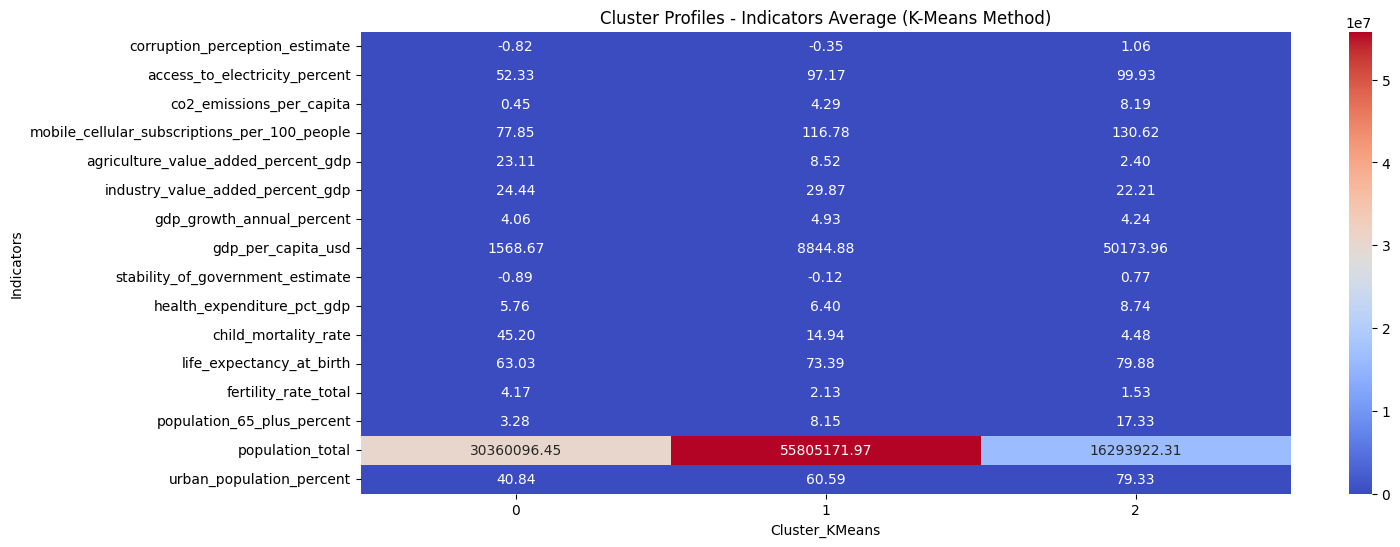

In [9]:
# 2. Analyze the "profile" of each cluster
cluster_profiles = df.groupby('Cluster_KMeans').mean(numeric_only=True)

plt.figure(figsize=(15, 6))
sns.heatmap(cluster_profiles.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Cluster Profiles - Indicators Average (K-Means Method)')
plt.ylabel('Indicators')
plt.show()

In [10]:
# 3. View some countries from a specific cluster for better understanding
print("\nExample: Top 10 countries in Cluster 0:")
print(df[df['Cluster_KMeans'] == 0]['Country Name'].head(10))

print("\nExample: Top 10 countries in Cluster 1:")
print(df[df['Cluster_KMeans'] == 1]['Country Name'].head(10))

print("\nExample: Top 10 countries in Cluster 2:")
print(df[df['Cluster_KMeans'] == 2]['Country Name'].head(10))


Example: Top 10 countries in Cluster 0:
0                  Afghanistan
5                       Angola
20                       Benin
30                Burkina Faso
31                     Burundi
34                    Cameroon
37    Central African Republic
38                        Chad
43                     Comoros
44            Congo, Dem. Rep.
Name: Country Name, dtype: object

Example: Top 10 countries in Cluster 1:
1                 Albania
2                 Algeria
6     Antigua and Barbuda
7               Argentina
8                 Armenia
12             Azerbaijan
14                Bahrain
15             Bangladesh
17                Belarus
19                 Belize
Name: Country Name, dtype: object

Example: Top 10 countries in Cluster 2:
3     American Samoa
4            Andorra
9              Aruba
10         Australia
11           Austria
13      Bahamas, The
16          Barbados
18           Belgium
21           Bermuda
29          Bulgaria
Name: Country Name, dtype: ob

## HDBSCAN

This section applies the HDBSCAN clustering algorithm to the scaled data. Unlike K-Means, HDBSCAN does not require pre-defining the number of clusters. This section includes steps to apply the algorithm and visualize the results, similar to the analysis performed for K-Means.

In [13]:
# Applying HDBSCAN
hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=5,
                                    min_samples=None,
                                    gen_min_span_tree=True)

clusters = hdbscan_clusterer.fit_predict(X_scaled)

# Adding the results to the DataFrame
df['Cluster_HDBSCAN'] = clusters

### Analysis and interpretation of results

In [14]:
# 1. View the distribution of countries by cluster
print("\nCountry count per cluster:")
print(df['Cluster_HDBSCAN'].value_counts().sort_index())


Country count per cluster:
Cluster_HDBSCAN
-1     94
 0     18
 1    105
Name: count, dtype: int64


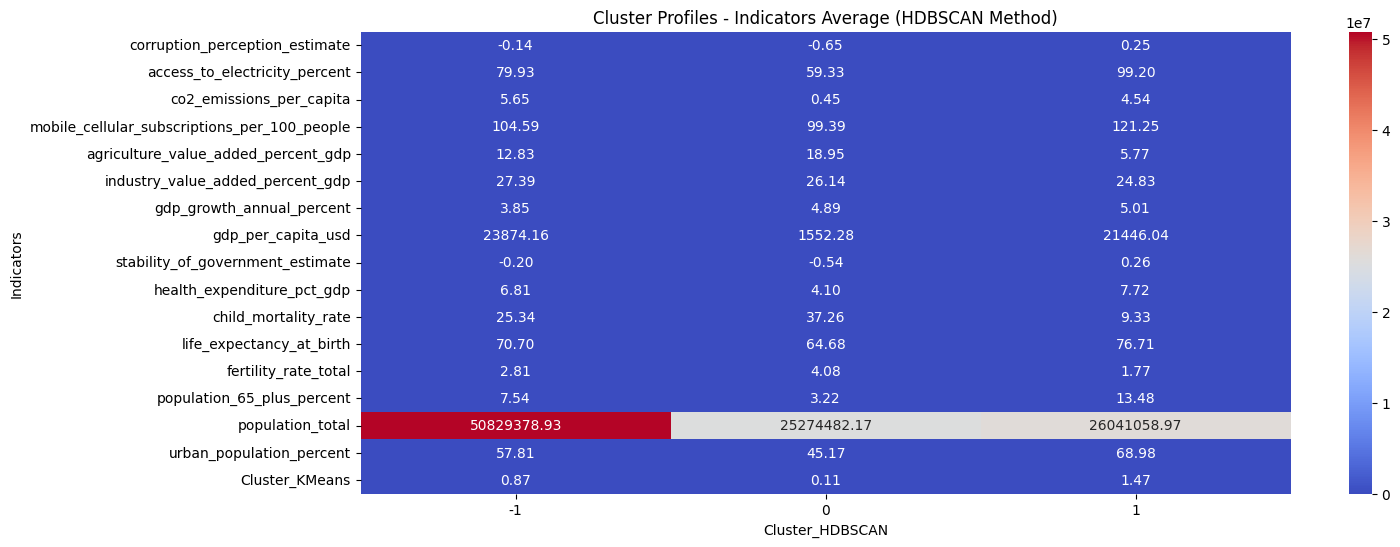

In [15]:
# 2. Analyze the "profile" of each cluster
cluster_profiles = df.groupby('Cluster_HDBSCAN').mean(numeric_only=True)

plt.figure(figsize=(15, 6))
sns.heatmap(cluster_profiles.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Cluster Profiles - Indicators Average (HDBSCAN Method)')
plt.ylabel('Indicators')
plt.show()

In [16]:
# 3. View some countries from a specific cluster for better understanding
print("\nExample: Top 10 countries in Cluster -1:")
print(df[df['Cluster_HDBSCAN'] == -1]['Country Name'].head(10))

print("\nExample: Top 10 countries in Cluster 0:")
print(df[df['Cluster_HDBSCAN'] == 0]['Country Name'].head(10))

print("\nExample: Top 10 countries in Cluster 1:")
print(df[df['Cluster_HDBSCAN'] == 1]['Country Name'].head(10))


Example: Top 10 countries in Cluster -1:
0             Afghanistan
6     Antigua and Barbuda
12             Azerbaijan
14                Bahrain
21                Bermuda
22                 Bhutan
25               Botswana
28      Brunei Darussalam
30           Burkina Faso
31                Burundi
Name: Country Name, dtype: object

Example: Top 10 countries in Cluster 0:
5             Angola
20             Benin
34          Cameroon
47     Cote d'Ivoire
61           Eritrea
71       Gambia, The
74             Ghana
81            Guinea
101            Kenya
118       Madagascar
Name: Country Name, dtype: object

Example: Top 10 countries in Cluster 1:
1            Albania
2            Algeria
3     American Samoa
4            Andorra
7          Argentina
8            Armenia
9              Aruba
10         Australia
11           Austria
13      Bahamas, The
Name: Country Name, dtype: object


## Exporting the Results

In [19]:
# Save the file in the current folder (WDI-2022-clustering)
output_csv_path = 'WDI2022_clusters.csv'
df.to_csv(output_csv_path, index=False)

## Analysis of Clustering Results (K-Means vs. HDBSCAN)

This section provides a summary and comparison of the clustering results obtained using K-Means and HDBSCAN.

### K-Means Analysis

Based on the Elbow Method and Silhouette Analysis, K=3 was chosen as the optimal number of clusters for the K-Means algorithm.

- **Cluster 0:** Characterized by lower values across most development indicators (e.g., lower GDP per capita, higher child mortality, lower life expectancy). This cluster appears to represent countries with lower levels of socioeconomic development.
- **Cluster 1:** Represents a transitional group with moderate values for most indicators. These countries are generally more developed than those in Cluster 0 but less so than those in Cluster 2.
- **Cluster 2:** Shows higher values for development indicators (e.g., higher GDP per capita, lower child mortality, higher life expectancy). This cluster likely represents more developed countries.

The K-Means approach provides a clear partitioning of countries into three distinct groups based on the chosen indicators. The heat map of cluster profiles clearly illustrates the average characteristics of each cluster.

### HDBSCAN Analysis

HDBSCAN identified three clusters (-1, 0, and 1), with cluster -1 representing noise points (outliers) that do not fit well into any specific cluster.

- **Cluster -1 (Noise):** This group contains countries that are significantly different from the core clusters, likely due to extreme values in some indicators.
- **Cluster 0:** Similar to a sub-group identified by K-Means, this cluster appears to contain countries with relatively low development indicators, although it is a smaller group than the K-Means Cluster 0.
- **Cluster 1:** This is the largest cluster and seems to group countries with higher development indicators, similar to K-Means Cluster 2 and some countries from K-Means Cluster 1.

HDBSCAN's strength lies in its ability to identify noise and clusters of varying densities. The noise cluster (-1) highlights countries that are outliers in the dataset based on the chosen features. The resulting clusters are not as evenly distributed as with K-Means, with a large number of countries falling into the noise category.

### Comparison and Interpretation

- **K-Means** successfully divided the countries into 3 distinct and well-balanced clusters, which clearly represent different levels of socioeconomic development.
- **HDBSCAN**, on the other hand, identified 2 main clusters but struggled with the continuous nature of the socioeconomic data. It resulted in a very large number of outliers (Cluster -1) and a significantly small Cluster 0 (which seemingly represented countries with lower indicators). Because HDBSCAN relies on dense regions to form clusters, it failed to categorize many countries that have unique or dispersed indicator profiles.

### Conclusion

Given the distribution of global development data, the **K-Means algorithm provided a much more precise, interpretable, and valuable clustering solution** compared to HDBSCAN. Therefore, the K-Means clusters were chosen as the final grouping to be used in the interactive dashboard.